# Dimensionality reduction techniques comparison

2026: **[Thomas Carreau](mailto:carreau@lpccaen.in2p3.fr)**, Laboratoire de Physique Corpusculaire de Caen, Caen, France.

2025:
- **[Hadrien Vroylandt](mailto:hadrien.vroylandt@unicaen.fr)**, GREYC, Caen, France.
- **[Kaciel Béraud]**, Laboratoire de Physique Corpusculaire de Caen, Caen, France.

Date: **23 September 2026**

# Objectives

This session will aim to learn how to play with some data and do some basic classification using classical methods using the [Scikit Learn](https://scikit-learn.org/stable/) and [UMAP learn](https://umap-learn.readthedocs.io/en/latest/) library.

The objectives of this session is to be able to classify the a dataset into there respective class using different classification technics. You will play with some data to understand the technics and apply what you've learn to a new dataset.

## Required Libraries

We suppose you still have the libraries from last lesson, today you will also needs:

* [Seaborn](https://seaborn.pydata.org/) to plot some heatmaps.

* [UMAP](https://umap-learn.readthedocs.io/en/latest/) to perform Uniform Manifold Approximation and Projection for Dimension Reduction. The package name is `umap-learn`

## Dataset

We will use the Wine dataset from Scikitlearn (UCI). It's composed of 178 wine analysis from 3 different producer. 

Here's the list of the features available: 

* alcohol
* malic_acid
* ash
* alcalinity_of_ash
* magensium
* total_phenols
* flavanoids
* nonflavanoid_phenols
* proanthocyanins
* color_intensity
* hue
* od280od315_of_diluted_wines
* proline

Over 3 different classes, 0, 1 and 2.

One can load and take a look at the dataset using the following code

In [140]:
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
from IPython.display import display # to show the dataframes nicely

# You can load the data like
# as_frame = True allow one to get a dataframe
data = load_wine(as_frame = True)

print(data.keys())

frame = data["frame"] # take the frame, which also contains the target class
df = pd.DataFrame(frame) # put it as a pandas

display(df)

print(df.shape)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


(178, 14)


In [141]:
data.data


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


The loaded dataset is a dictionnary containing the data, features and some metadata. 

The `as_frame` argument allow to keep the column name, which is easier to represent, but for a computation purpose, we will not keep them.

The data is stored using a numpy array, it contains the 13 features with 178 observations and we can convert it to a pandas dataframe to work on them.

You can explore the dataset and try to find some correlation by hands.

## Exercise 1

Explore the data by plotting 1 dimension histogram of the features.

Use the `target` class to select along the group and look at the distribution with and without the selection.

Can you find easy discrimination variable in the data?

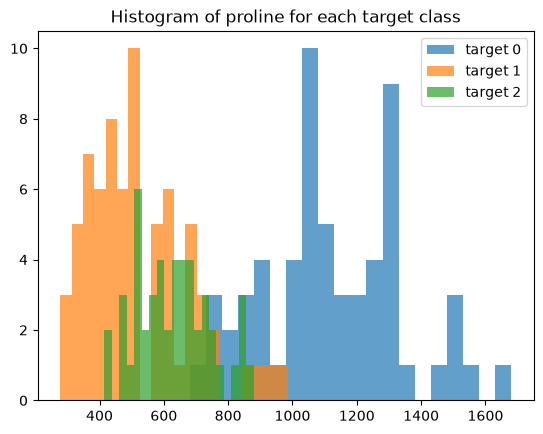

In [142]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolor

feature_columns = "proline"


# Explore the data
grouped = df.groupby("target")
groups = list(grouped.groups.keys())

for group in groups:
    plt.hist(grouped.get_group(group)[feature_columns], bins = 20, alpha = 0.7, label = f"target {group}")

plt.title(f"Histogram of {feature_columns} for each target class")
plt.legend()
plt.show()
    

## Exercise 2

Now try to use a second variable and plot 2 dimensions histogram of the features.

Again, use the `target` class to select along the group and look at the distribution with and without the selection.

Can you find better way of discriminating the data? Is it enough?

Text(0.04, 0.5, 'proline')

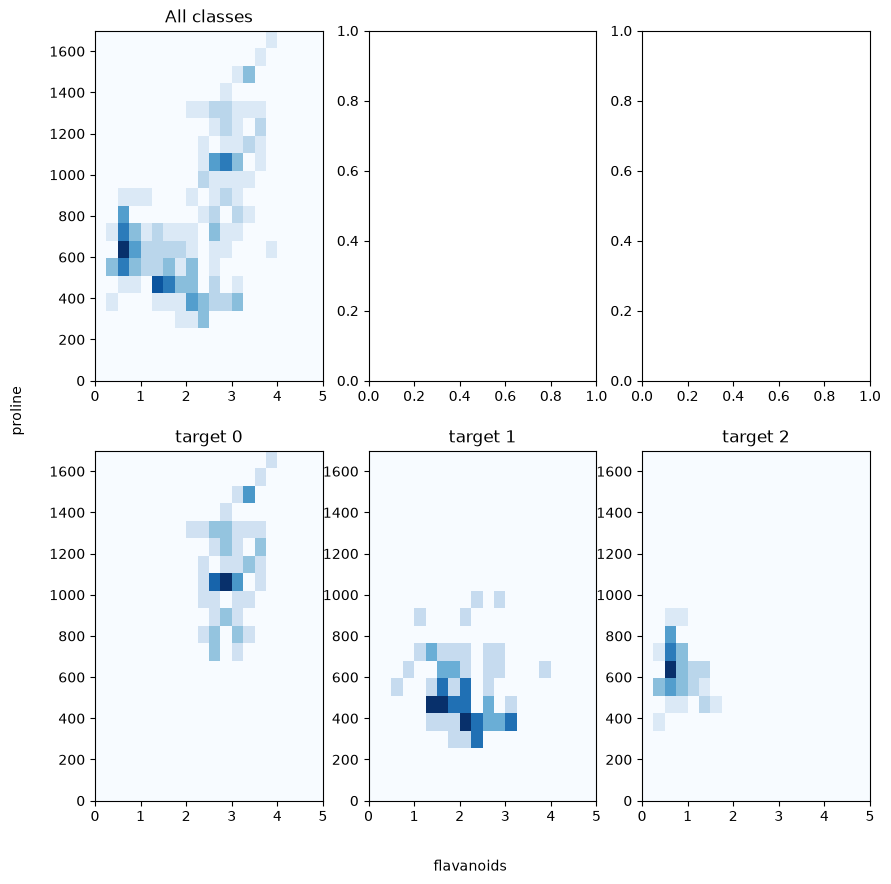

In [143]:
# Explore the data, but in 2D
feature_columns = ["flavanoids" , "proline"]
target_column = "target"
target_number = 0
grouped = df.groupby("target")
groups = list(grouped.groups.keys())
grouped_feature = grouped[feature_columns + [target_column]].apply(lambda x: x)
grouped_feature.reset_index(drop = True, inplace = True)
fig , ax = plt.subplots(figsize = (10, 10) , nrows = 2 , ncols = 3)
ax[0, 0].hist2d(grouped_feature[feature_columns[0]], grouped_feature[feature_columns[1]], bins = 20, cmap = "Blues" , range=[[0,5], [0,1700]])
ax[0, 0].set_title("All classes")
for i in groups:
    class_selected = grouped_feature[grouped_feature[target_column] == i]
    ax[1, i].hist2d(class_selected[feature_columns[0]], class_selected[feature_columns[1]], bins = 20, cmap = "Blues", range=[[0,5], [0,1700]])
    ax[1, i].set_title(f"target {i}")
fig.text(0.5, 0.04, feature_columns[0], ha='center')
fig.text(0.04, 0.5, feature_columns[1], va='center', rotation='vertical')


# Dimension reduction

We can manually discreminate up to 2 or even 3 dimensions, but since we have 13 of them, it's impossible to do by hands. That's why we can use **Dimension Reduction** technics, this consist in finding the distances between the points in a hyperspace. The methods can be viewed as geometric even if we are not in a 3D space

For computation purpose, we do not keep the columns names and only get a numpy matrix. We also do not include the target in the features, which will defeat the purpose of the dimension reduction technics.

Before we start, we can prepare a few visualization functions that will be useful.

In [185]:
# Override the data to remove the labels name
data = load_wine(as_frame = False)
features = data["data"]
labels = data["target"]
features_names = data["feature_names"]
print(len(labels))

178


In [145]:
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#%matplotlib widget

def visualize_2d(x, labels):
    sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=labels, s=100, alpha=0.8,
                    palette="viridis", edgecolor="black")
    plt.show()

def visualize_3d(x, labels, elev = 30, azim = 45, roll = 0):
    # Workaround as axis limits are not auto-scaling
    x_norm = (x - x.min(axis=0)) / (x.max(axis=0) - x.min(axis=0))
    x, y, z = x_norm[:, 0], x_norm[:, 1], x_norm[:, 2]

    # Colors
    cmap = plt.get_cmap('viridis', 3)
    color = cmap(labels)
    fig = plt.figure(figsize = (7,7))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(x, y, z, marker="o", c = color)
    ax.view_init(elev = elev, azim = azim, roll = roll) # if roll give errors, just remove it from this line
    plt.show()

## Correlation matrix

One of the first thing to understand a dataset is to compute the correlation coefficients matrix and then computing the eigenvectors and eigenvalues. This matrix will show the correlation between each features, it's an easy way to find which feature are corrolated with another one.

This can be done manually or using numpy's functions:

In [146]:
len(df.columns)

14

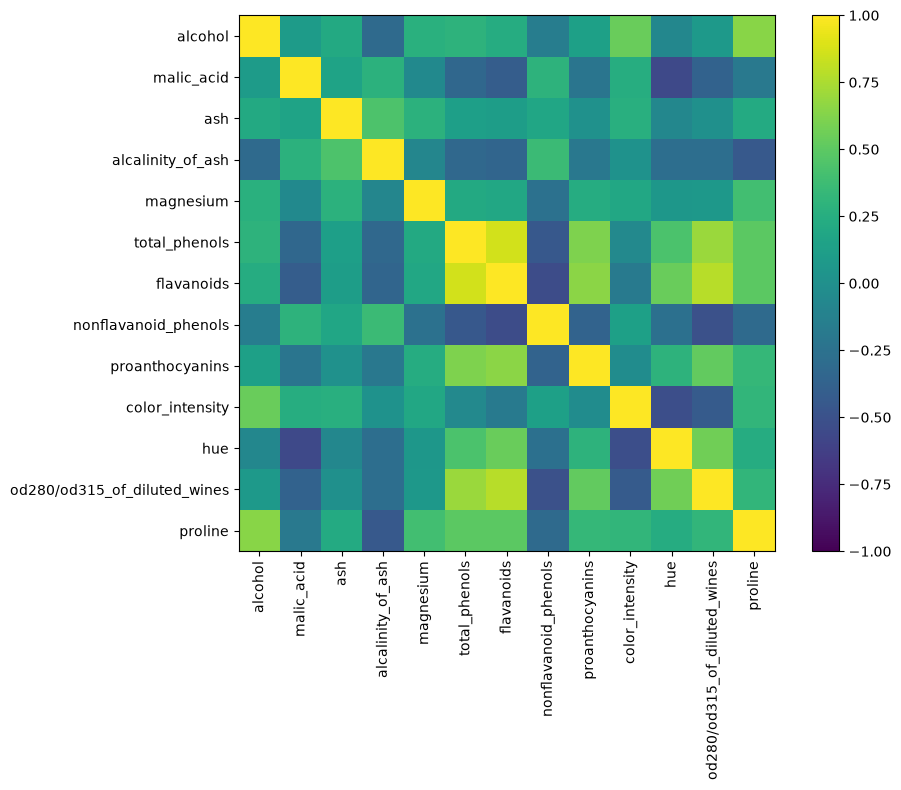

In [147]:
# We have to transpose the matrix to get the correlation coefficient of the features
cov = np.corrcoef(features.T)
eig_vals, eig_vecs = np.linalg.eig(cov)
plt.figure(figsize=(10, 8))
plt.imshow(cov, vmin=-1, vmax=1)

plt.xticks(range(len(features_names)), features_names, rotation=90)
plt.yticks(range(len(features_names)), features_names)

plt.colorbar()
plt.tight_layout()
plt.show()

Note that we need to transpose the matrix, if you do not make the transpose, you will get the correlation coefficient of each observation with another.

## PCA

The first method of dimension reduction is the PCA meaning "Principal Component Analysis". The data are linearly transform into a new coordinate system to capture the largest variation in the data.

Here using Scikit Learn's decomposition submodule, we can use directly the PCA to look at our features.

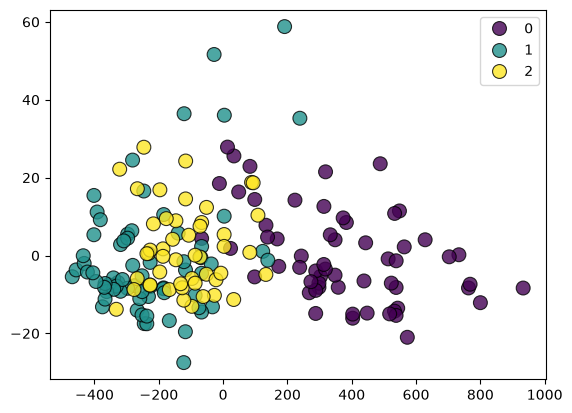

In [148]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_2d = pca.fit_transform(features)
visualize_2d(x = pca_2d, labels = labels)
#correlation of the highest pca

This graph represents the in the x axis the valuesof the first principal component and in the y axis the values of the second principal component. Notice that it is a nice way to separate the data into classes with just two dimensions. Each point is then a point in the dataset

Which you can also get the eigenvectors and eigenvalues of the PCA. We that the eignevalues correspond to the x and y dispersion.

You also have the two component of the eigenvectors for each feature.

In [149]:
print("Eigenvalues: \n", pca.explained_variance_ratio_) # variance explained by each component , amplitude of the contribution to dispersion
print("Eigenvectors: \n", pca.components_)

Eigenvalues: 
 [0.99809123 0.00173592]
Eigenvectors: 
 [[ 1.65926472e-03 -6.81015556e-04  1.94905742e-04 -4.67130058e-03
   1.78680075e-02  9.89829680e-04  1.56728830e-03 -1.23086662e-04
   6.00607792e-04  2.32714319e-03  1.71380037e-04  7.04931645e-04
   9.99822937e-01]
 [ 1.20340617e-03  2.15498184e-03  4.59369254e-03  2.64503930e-02
   9.99344186e-01  8.77962152e-04 -5.18507284e-05 -1.35447892e-03
   5.00440040e-03  1.51003530e-02 -7.62673115e-04 -3.49536431e-03
  -1.77738095e-02]]


Setting the number of components of the PCA allow us to find the 2 most important features in the dataset, which are:

In [150]:
print(f"First most contributing component: '{features_names[np.argmax(pca.components_[0])]}' contributaing at: , {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Second most contributing component: '{features_names[np.argmax(pca.components_[1])]}' contributing at: {pca.explained_variance_ratio_[1]*100:.2f}%")

First most contributing component: 'proline' contributaing at: , 99.81%
Second most contributing component: 'magnesium' contributing at: 0.17%


We can also increase the number of components to match the number of dimension, it will sort each component into there respective contribution.

In [151]:
pca = PCA(n_components = 13)
pca_2d = pca.fit_transform(features)
print("Eigenvalues: \n", pca.explained_variance_ratio_)
print("Eigenvectors: \n", pca.components_)

Eigenvalues: 
 [9.98091230e-01 1.73591562e-03 9.49589576e-05 5.02173562e-05
 1.23636847e-05 8.46213034e-06 2.80681456e-06 1.52308053e-06
 1.12783044e-06 7.21415811e-07 3.78060267e-07 2.12013755e-07
 8.25392788e-08]
Eigenvectors: 
 [[ 1.65926472e-03 -6.81015556e-04  1.94905742e-04 -4.67130058e-03
   1.78680075e-02  9.89829680e-04  1.56728830e-03 -1.23086662e-04
   6.00607792e-04  2.32714319e-03  1.71380037e-04  7.04931645e-04
   9.99822937e-01]
 [ 1.20340617e-03  2.15498184e-03  4.59369254e-03  2.64503930e-02
   9.99344186e-01  8.77962152e-04 -5.18507284e-05 -1.35447892e-03
   5.00440040e-03  1.51003530e-02 -7.62673115e-04 -3.49536431e-03
  -1.77738095e-02]
 [ 1.68738094e-02  1.22003373e-01  5.19874304e-02  9.38593003e-01
  -2.97802484e-02 -4.04846439e-02 -8.54433387e-02  1.35107797e-02
  -2.46593824e-02  2.91398464e-01 -2.59776624e-02 -7.03239693e-02
   4.52868159e-03]
 [ 1.41446778e-01  1.60389543e-01 -9.77280992e-03 -3.30965260e-01
  -5.39375605e-03 -7.45846556e-02 -1.69086724e-01  1

We can see that the amount of information carried by each dimension fall down very quickly.

Mathematically, each eigenvalue of the covariance matrix (which is what we calculate under the hood when doing PCA) gives the variance along the corresponding principal component.

## 3D Projection

We can represent data up to 3 dimension, using the same snippet of code, but we set the number of component to 3.

With a third component, we might see a separation between the group, which we can visualized with a 3D scatter plot:

In [152]:
import plotly.express as px

pca = PCA(n_components=3)
pca_3d = pca.fit_transform(features)

fig = px.scatter_3d(
    pca_3d, x=0, y=1, z=2,
    color=[f"Class {label}" for label in labels],
    labels={
        str(i): f"PC{i+1} ({ratio:.1%} variance)"
        for i, ratio in enumerate(pca.explained_variance_ratio_)
    },
    title="3D PCA — drag to rotate",
    opacity=0.8,
    height=650,
)
fig.update_traces(marker_size=5)
fig.show()

You can make the plot rotate by adding an angle, the first one is the elevation and the second one is the azymut.

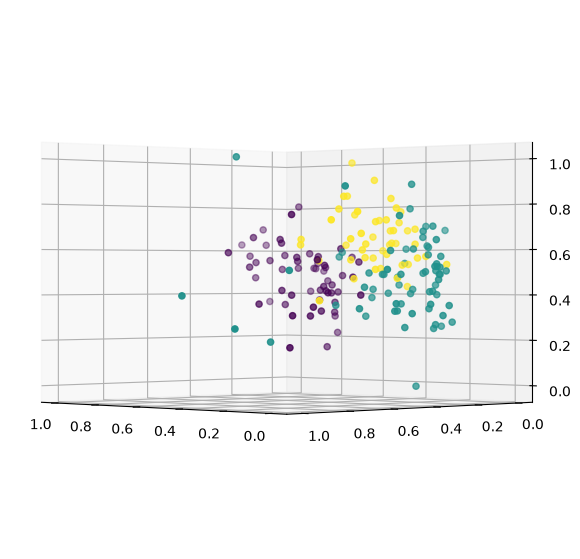

In [153]:
visualize_3d(pca_3d, labels, 0, 135)

### Classification

After one **Dimension Reduction** analysis, you can add a new dimension in your data which can be a first classification to orientate future steps.

This can be done using **NumPy's array** and a seperation function. In our case, we cannot discriminate easily between class 2 and 3, so we will just separate between class 0 and the other classes;

In [154]:
def separation_function(x, y) :
    if x > 180 :
        r_val = 0
    else :
        r_val = 1
    return r_val

l = []
for pos in pca_2d : # we loop over each pair of points
    l.append(separation_function(pos[0], pos[1]))

np_l = np.array(l)
features = np.c_[features, np_l]


`np.c_[]` allows you to append a column in a **NumPy's matrix** and `np.r_[]` is the row equivalent. Other functions like `np.concatenate` exists using a different syntax, you can choose between them depending on how you handle the data.

After the classification, we can measure the quality of the separation by computing the number of **True positives** versus the number of **False positive**.

In our case we can check the quality of the classification of the `class_0` versus the others:

In [155]:
print(f"Number of real class 0 observations: {np.count_nonzero(labels == 0)}")
print(f"Number of separated class 0: {np.count_nonzero(features[:,-1] == 0)}") # -1 is the last column
print(f"Number of True Positives: {np.count_nonzero((features[:,-1] == 0) & (labels == 0))}")
print(f"Number of False Positives: {np.count_nonzero((features[:,-1] == 0) & (labels != 0))}")

Number of real class 0 observations: 59
Number of separated class 0: 48
Number of True Positives: 46
Number of False Positives: 2


We see that we only have 2 **False Positives** in the separation of the `class_0` but we still miss 13 observations that are excluded by our cut. When choosing a cut like that, you want to have the highest number of **True Positives** with the lowest amount of **False Positives** and the cut you will take is always a compromised between them.

Doing this comparaison with a multitudes of cut will give you a **ROC curve**. ( Receiver Operating Characteristic Curve)

## MDS

MDS stands for **Multidimensional scaling**, it's another method of Dimension reduction, this time it's a non-linear one.

This method take in input a matrix with the distances between each pair of objects. The result of the MDS will also be affected by the distance algorithm used.

We start by computing the distance in a latent space for each pair of observations:

In [156]:
from sklearn.metrics.pairwise import manhattan_distances

d_matrix = manhattan_distances(features)
d_matrix.shape

(178, 178)

Then, we can plot the matrix nicely, here we only plot 10 pair because the matrix can get too big really quickly.

Distance matrix of the first 10 data points...


<Axes: >

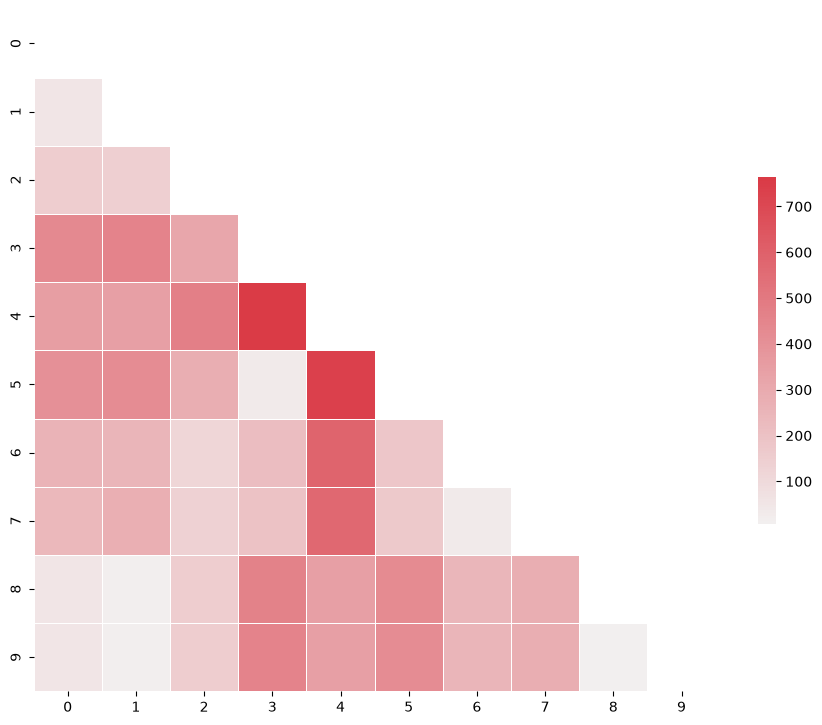

In [157]:
import seaborn as sns
print("Distance matrix of the first 10 data points...")
distances = d_matrix[:10, :10]

mask = np.triu(np.ones_like(distances, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(distances, mask=mask, cmap=cmap, vmax=distances.max(), center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Or we can simply plot the whole matrix like we did before;

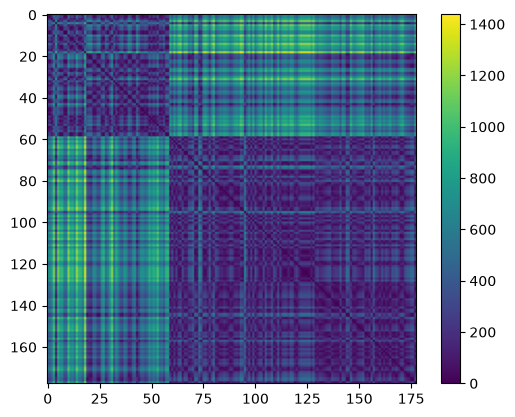

In [158]:
plt.imshow(d_matrix)
plt.colorbar()
plt.show()

Note: You can see 3 clusters of point, it's because the data are sorted by targets. If the data was shuffle this structure will not be visible.

Now that we have computed the Manhattan Distances, we can now compute the MDS.

Note it works better with Manhattan distances than the euclidean distance, it's most likely a high dimension problem.

In [159]:
import plotly.express as px

fig = px.scatter_3d(
    mds_3d, x=0, y=1, z=2,
    color=[f"Class {label}" for label in labels],
    labels={"0": "MDS 1", "1": "MDS 2", "2": "MDS 3",
            "color": "Wine class"},
    title="Interactive 3D MDS",
    opacity=0.8,
    height=650,
)
fig.update_traces(marker_size=5)
fig.update_layout(scene=dict(dragmode="orbit", aspectmode="data"))
fig.show()

What MDS effectively does is find coordinates z in $\mathbb{R}^n$ , n being the number of components chosen that minimize the stress function , meaning

$$
S = \sum_{i<j} \left(D_{ij} - \|z_i - z_j\|_2\right)^2
$$

Where $$D_{ij}$$ is the manhattan distance between to points in the dataset. The minimisation of this function can be solved with a lot of different optimizers. In this case the SMACOF optimizer was used.


We can print the "stress", which is the sum of squared distance of the disparities and the distances for all constrained points. if you put `normalized_stress = True` and `metric = False`, you will have normalized stress in which 0 means "perfect" fit, 0.025 excellent, 0.05 good, 0.1 fair, 0.2 poor.

In [160]:
print("Stress:", mds.stress_)

Stress: 38647.75137895184


Same as before, we can put 2 component instead of 3.

In this case we pass directly the features and the **Euclidean distances** will be used. You can compare the difference of the results using the `dissimilarity` argument.

c:\Users\josev\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\josev\miniconda3\envs\machine_learning\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


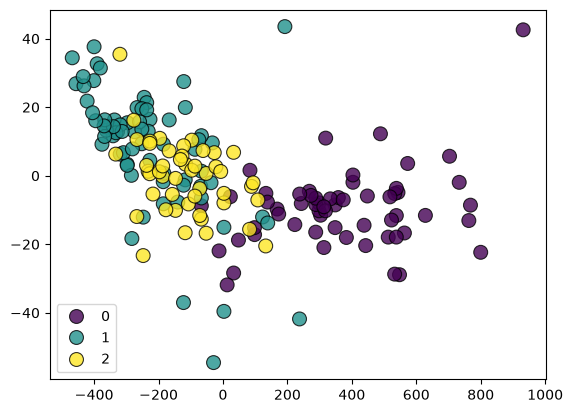

In [161]:
mds = MDS(n_components=2, normalized_stress=False, eps=1e-9, random_state=2024, dissimilarity="euclidean")
mds_2d = mds.fit_transform(features)
visualize_2d(mds_2d, labels)

## t-SNE

Another technic is the t-SNE, meaning **t-distributed Stocashtic Neighbor embedding**. It's a statistical method with the same objectives as the ones before but based on another algorithm.

Same as before, we can do this using 2 or 3 components;

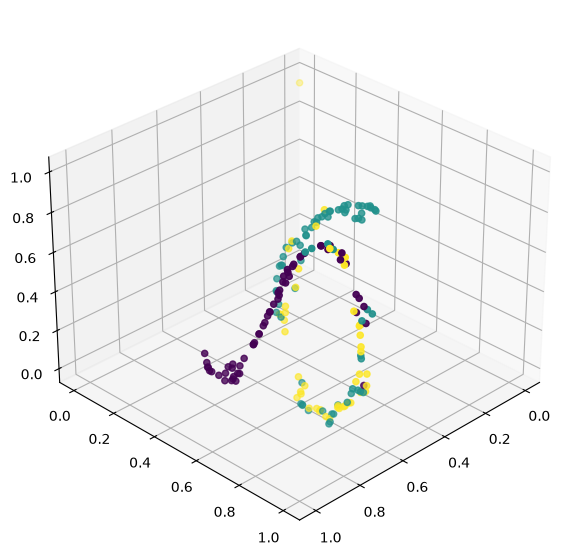

In [162]:
from sklearn.manifold import TSNE

tsne_3d = TSNE(n_components=3, perplexity=10, early_exaggeration=12, learning_rate='auto', init='pca', n_jobs=4).fit_transform(features)
visualize_3d(tsne_3d, labels)

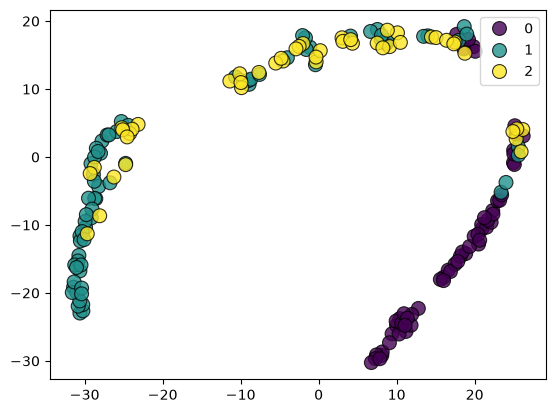

In [163]:
tsne_2d = TSNE(n_components=2, perplexity=10, early_exaggeration=12, learning_rate='auto', init='random', n_jobs=4).fit_transform(features)
visualize_2d(tsne_2d, labels)

**t-SNE** stands for **t-distributed Stochastic Neighbor Embedding**. It converts similarities between the original observations into probabilities $p_{ij}$ and defines corresponding probabilities $q_{ij}$ in the reduced space using a Student's t-distribution. It finds positions that minimize the **Kullback–Leibler divergence**:

$$
C_{\text{t-SNE}} = \sum_{i \ne j} p_{ij}
\log\left(\frac{p_{ij}}{q_{ij}}\right)
$$

Here, $p_{ij}$ is large when observations $i$ and $j$ are similar in the original space. Minimizing this objective encourages those observations to remain close in the visualization. The method mainly preserves local neighborhoods, so distances between separate groups are not necessarily meaningful.



## UMAP

UMAP is one the most recent method, it's a variant of the t-SNE using a [Riemannian](https://en.wikipedia.org/wiki/Riemannian_manifold#Riemannian_metrics_and_Riemannian_manifolds) metric.

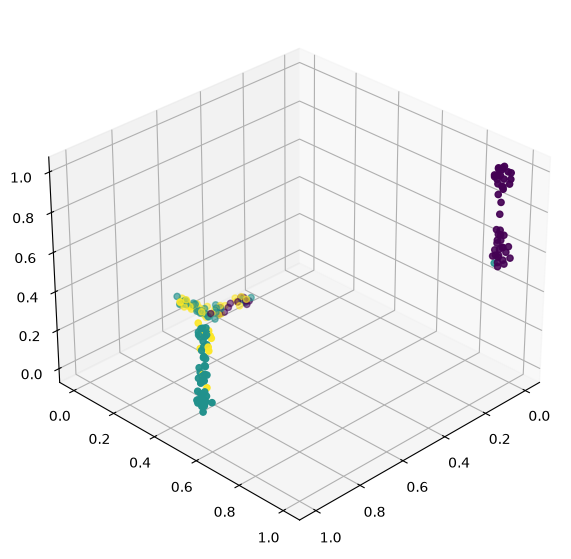

In [164]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, metric='euclidean')
umap_3d = reducer.fit_transform(features)
visualize_3d(umap_3d, labels)

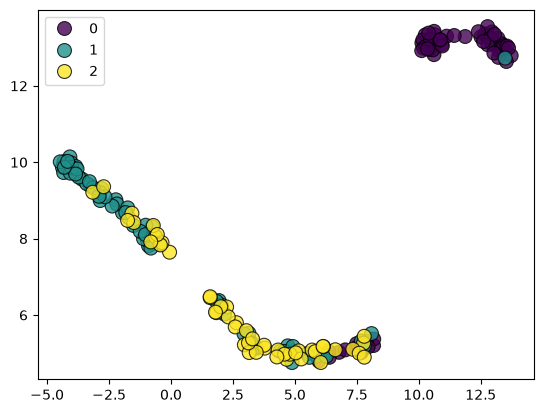

In [165]:
reducer = reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean')
umap_2d = reducer.fit_transform(features)
visualize_2d(umap_2d, labels)

In [166]:
import plotly.express as px

fig = px.scatter_3d(
    umap_3d, x=0, y=1, z=2,
    color=[f"Class {label}" for label in labels],
    labels={
        "0": "UMAP 1", "1": "UMAP 2", "2": "UMAP 3",
        "color": "Wine class",
    },
    title="Interactive 3D UMAP",
    opacity=0.8,
    height=650,
)
fig.update_traces(marker_size=5)
fig.update_layout(scene=dict(dragmode="orbit", aspectmode="data"))
fig.show()

**UMAP** stands for **Uniform Manifold Approximation and Projection**. It builds a graph whose weights $w_{ij}\in[0,1]$ describe how strongly observations are connected in the original space. For reduced coordinates $z_i$ and $z_j$, the connection strength is modeled as:

$$
v_{ij} = \frac{1}{1+a\|z_i-z_j\|_2^{2b}}
$$

The positive parameters $a$ and $b$ control the shape of this relationship. UMAP's theoretical cross-entropy objective, omitting terms independent of the coordinates, is:

$$
C_{\text{UMAP}} =
-\sum_{i<j}\left[
w_{ij}\log(v_{ij})
+(1-w_{ij})\log(1-v_{ij})
\right]
$$

The first term attracts strongly connected observations, while the second separates weakly connected observations. In practice, UMAP uses stochastic optimization with sampled edges and negative examples to approximate this optimization efficiently.

## Exercise 3

Load the Sloan Digital Sky Survey (SDSS) dataset and use the techniques seen before to correctly classify the data.

Add a column in the data to add another flag.

Quantify your cut by the amount of **true positives** and **false positives** counts.

In [167]:
!curl -L -o sdss-dr16-sloan-digital-sky-survey.zip\
  https://www.kaggle.com/api/v1/datasets/download/kriegersaurusrex/sdss-dr16-sloan-digital-sky-survey

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0

  0      0   0      0   0      0      0      0                              0
 17 34.67M  17  6.15M   0      0  4.38M      0   00:07   00:01   00:06  6.14M
 66 34.67M  66 22.92M   0      0  9.51M      0   00:03   00:02   00:01 11.42M
100 34.67M 100 34.67M   0      0 11.24M      0   00:03   00:03         11.42M
100 34.67M 100 34.67M   0      0 11.24M      0   00:03   00:03         11.42M
100 34.67M 100 34.67M   0      0 11.24M      0   00:03   00:03         11.42M


In [168]:
!unzip -o sdss-dr16-sloan-digital-sky-survey.zip

'unzip' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


Variables:
- `objid`: Unique Object Identifier
- `ra`: J2000 Right Ascension (r-band)
- `dec`: J2000 Declination (r-band)
- `u`: better of deV/Exp magnitude fit (u-band)
- `g`: better of deV/Exp magnitude fit (g-band)
- `r`: better of deV/Exp magnitude fit (r-band)
- `i`: better of deV/Exp magnitude fit (i-band)
- `z`: better of deV/Exp magnitude fit (z-band)
- `run`: Run Number
- `rerun`: Rerun Number
- `camcol`: Camera column
- `field`: Field number
- `specobjid`: Object Identifier
- `class`: object class (galaxy, star or quasar object)
- `redshift`: Final Redshift
- `plate`: plate number
- `mjd`: Median Julian Date of observation
- `fiberid`: fiberID 


In [169]:
df = pd.read_csv("Skyserver_12_15_2020 3 45 07 AM.csv", low_memory=False, skiprows=1).dropna()
df.describe()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,redshift,plate,mjd,fiberid
count,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.0,500000.000000,500000.000000,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000
mean,1.237663e+18,179.623572,24.224697,18.633613,17.410840,16.889312,16.557136,16.400860,3993.009854,301.0,3.452638,193.327454,2.957517e+18,0.174518,2626.717060,53946.006740,351.444894
std,7.216102e+12,77.436132,19.781558,0.830229,0.985165,1.131152,28.354221,28.357042,1680.137512,0.0,1.599127,147.866413,2.505174e+18,0.440989,2225.027429,1552.201116,216.503861
min,1.237646e+18,0.001914,-19.669456,10.170250,9.300097,8.814259,-9999.000000,-9999.000000,94.000000,301.0,1.000000,11.000000,2.994897e+17,-0.010111,266.000000,51578.000000,1.000000
25%,1.237658e+18,140.258629,7.298503,18.206547,16.850810,16.199750,15.869320,15.625370,2863.000000,301.0,2.000000,85.000000,1.351110e+18,0.000003,1200.000000,52734.000000,171.000000
50%,1.237662e+18,181.818457,22.699434,18.867320,17.517325,16.901080,16.613755,16.444210,3910.000000,301.0,3.000000,155.000000,2.364502e+18,0.045212,2100.000000,53757.000000,344.000000
75%,1.237667e+18,224.329227,39.084884,19.267930,18.060230,17.592930,17.355242,17.248760,5071.000000,301.0,5.000000,257.000000,3.279757e+18,0.096046,2913.000000,54594.000000,511.000000
max,1.237681e+18,359.999615,84.852149,19.600000,19.996050,33.209920,32.349170,30.017040,8162.000000,301.0,6.000000,1001.000000,1.317780e+19,7.011245,11704.000000,58543.000000,1000.000000


In [186]:

classification_columnn = df['class']
labels = classification_columnn.values 
len(labels)

499993

Dropping huge outliers in i and z parameter that seem like an error in acquisiton

In [ ]:
df = df[(df['i'] > 0) & (df['z'] > 0)]
# Refresh labels after filtering so they match the feature rows.
labels = df['class'].to_numpy()

In [172]:
columns_to_drop = ['objid' , 'run' , 'rerun' , 'fiberid' , 'field' , 'class' , 'specobjid']
features_df = df.drop(columns  = columns_to_drop , errors = 'ignore')
features = features_df.values
feature_names = features_df.columns


Correlation Matrix

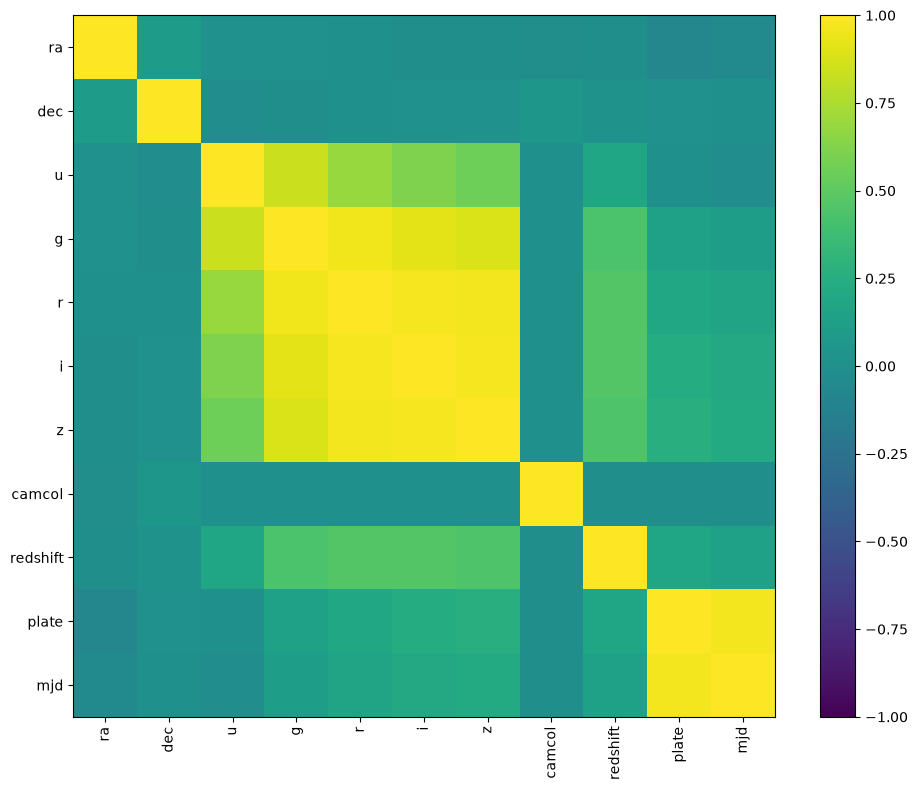

In [173]:
# We have to transpose the matrix to get the correlation coefficient of the features
cov = np.corrcoef(features.T)
eig_vals, eig_vecs = np.linalg.eig(cov)
plt.figure(figsize=(10, 8))
plt.imshow(cov, vmin=-1, vmax=1)

plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)

plt.colorbar()
plt.tight_layout()
plt.show()

From this analysis , whe can see that plate and mjd are strongly correlated , and also u, g and r are strongly correlated between them. This mean that  maybe they are candidates where we can observe some clusterization

Exploring some features

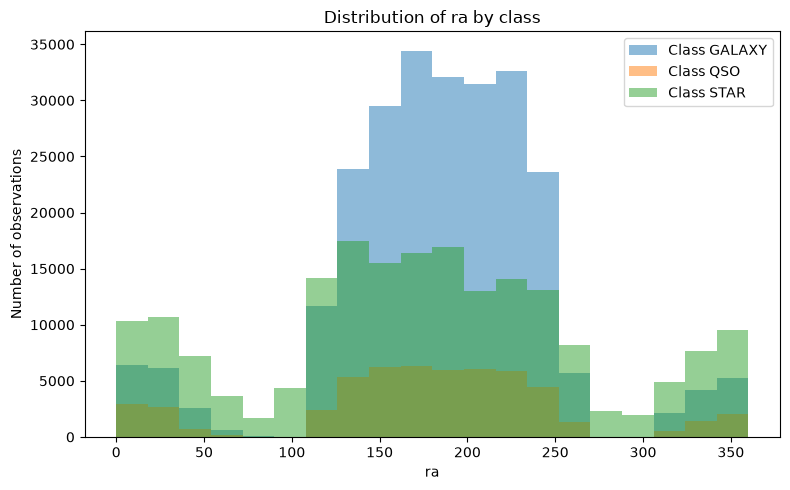

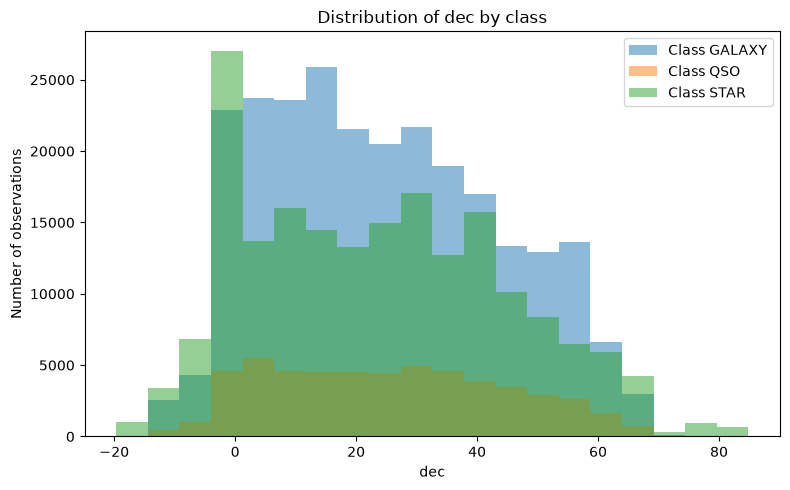

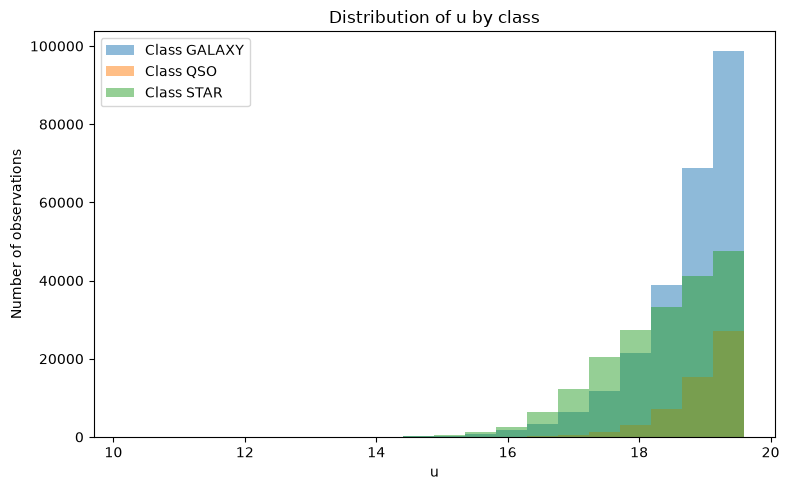

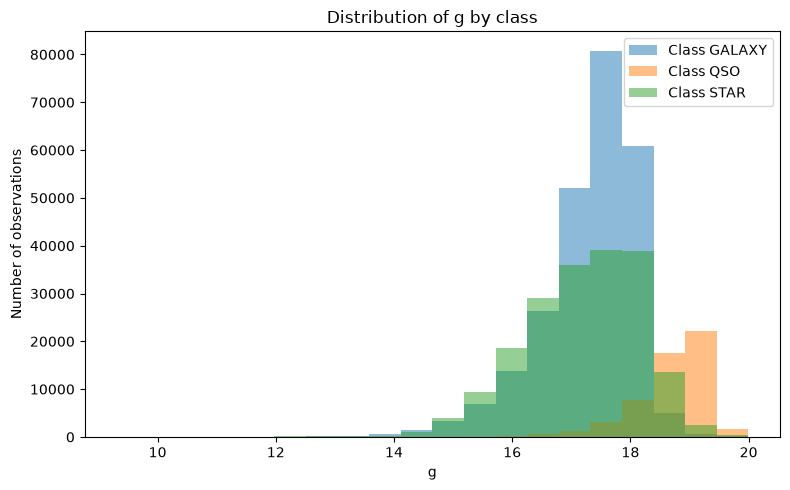

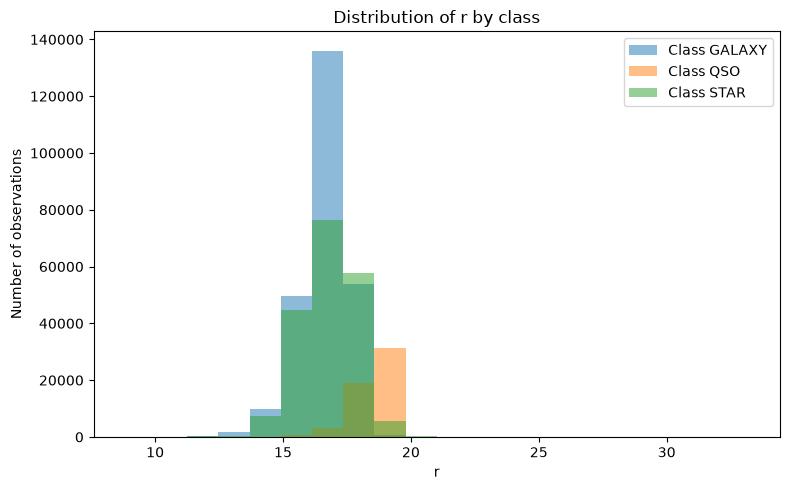

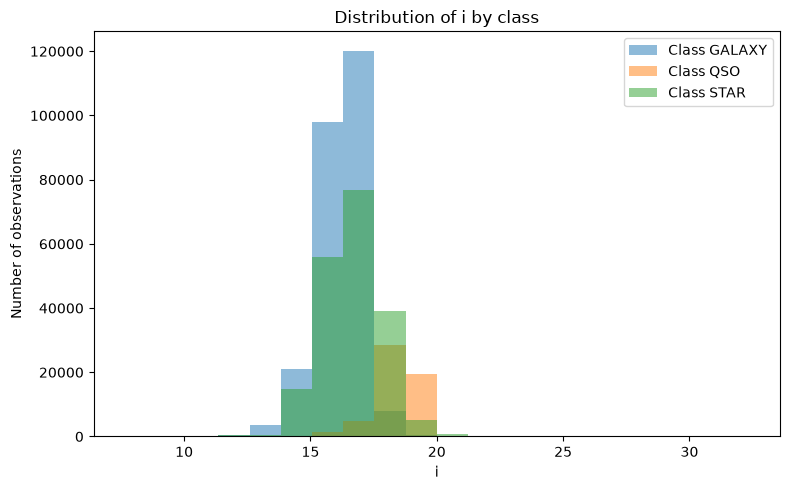

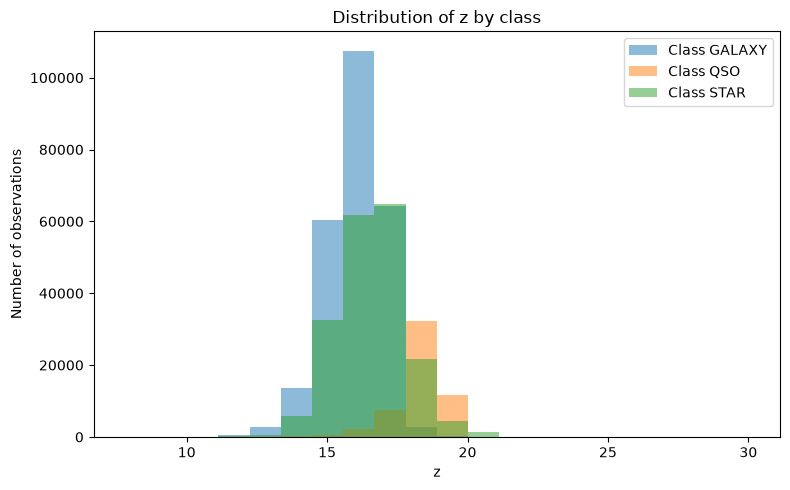

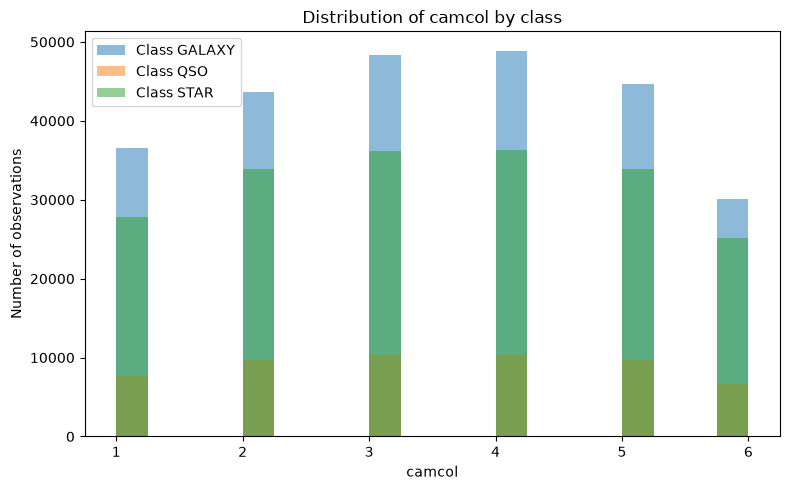

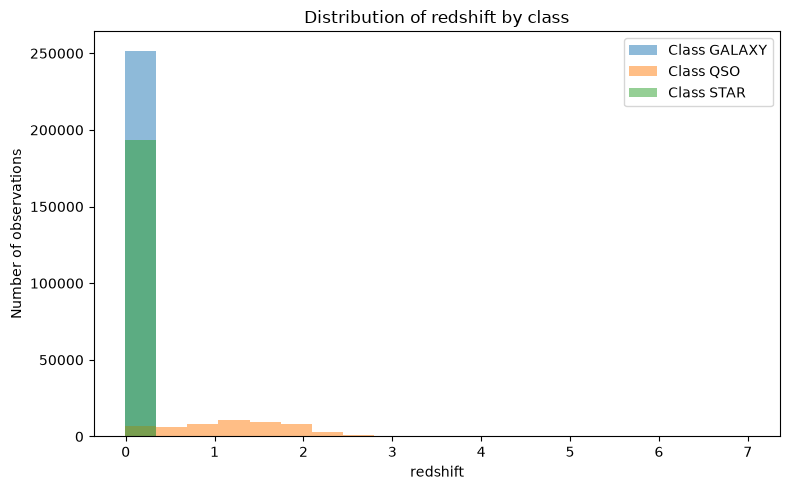

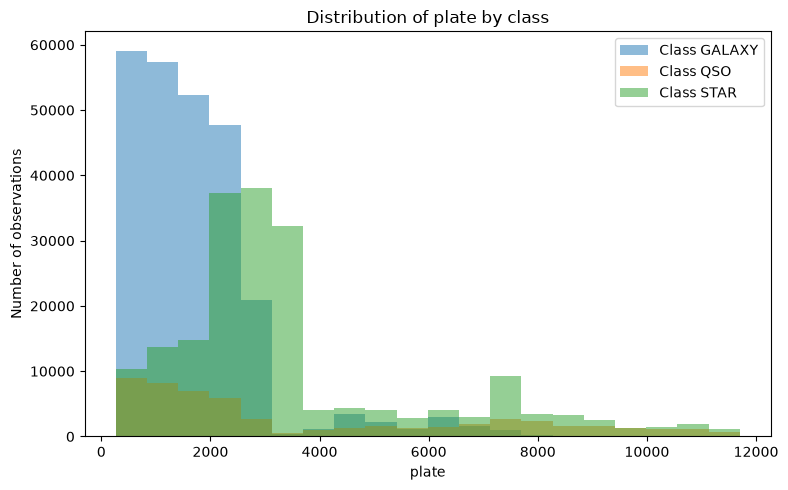

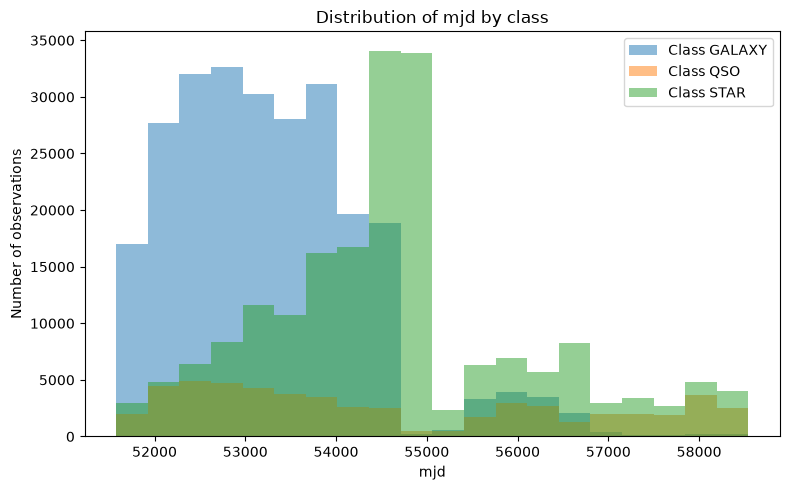

In [174]:
import numpy as np
import matplotlib.pyplot as plt

feature_columns = feature_names
grouped = df.groupby("class")

for feature in feature_columns:
    plt.figure(figsize=(8, 5))

    # Use the same bin boundaries for every class
    bins = np.histogram_bin_edges(df[feature].dropna(), bins=20)

    for group, group_df in grouped:
        plt.hist(
            group_df[feature].dropna(),
            bins=bins,
            alpha=0.5,
            label=f"Class {group}",
        )

    plt.title(f"Distribution of {feature} by class")
    plt.xlabel(feature)
    plt.ylabel("Number of observations")
    plt.legend()
    plt.tight_layout()
    plt.show()

CamCol doesent seem statiscally relevant as a feature, so its dropped

In [189]:
columns_to_drop = ['camcol']
features_df = features_df.drop(columns  = columns_to_drop , errors = 'ignore')
features = features_df.values
feature_names = features_df.columns

In [190]:
features_df.columns

Index(['ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'redshift', 'plate', 'mjd'], dtype='str')

Exploring plotting two features together

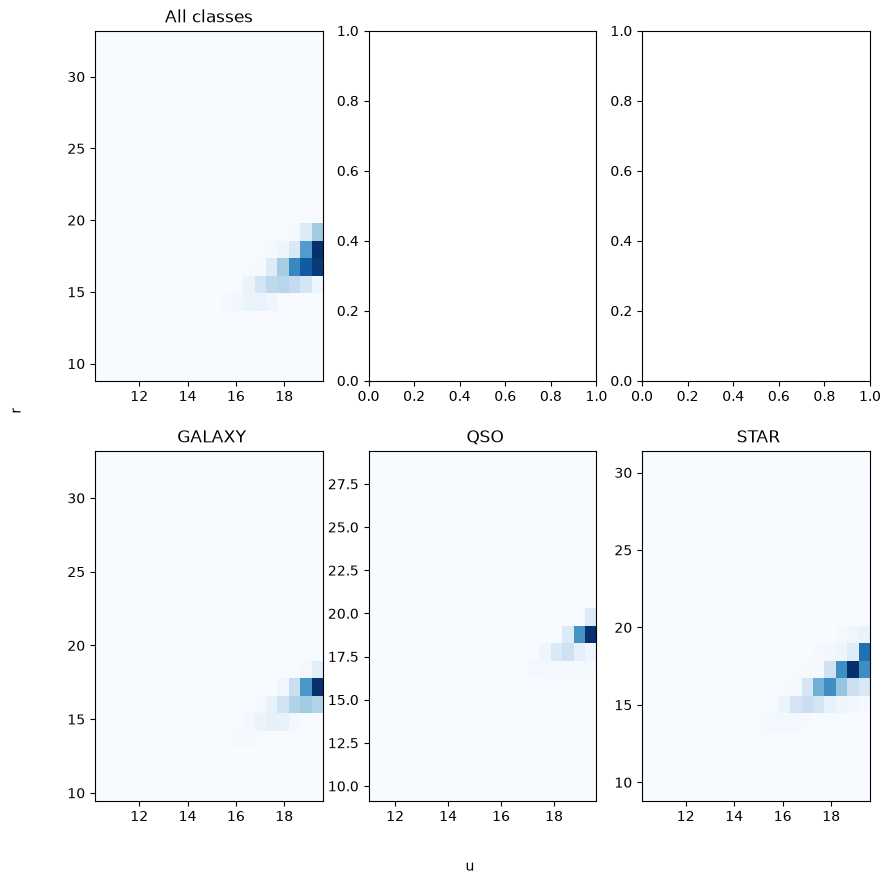

In [191]:
# Explore the data, but in 2D

def plot_2d_histogram(feature_columns : list):
    target_column = "class"
    grouped = df.groupby(target_column)
    groups = list(grouped.groups.keys())

    grouped_feature = grouped[feature_columns + [target_column]].apply(lambda x: x)
    grouped_feature.reset_index(drop = True, inplace = True)
    fig , ax = plt.subplots(figsize = (10, 10) , nrows = 2 , ncols = 3)
    ax[0, 0].hist2d(grouped_feature[feature_columns[0]], grouped_feature[feature_columns[1]], bins = 20, cmap = "Blues" )
    ax[0, 0].set_title("All classes")
    for i,name in enumerate(groups):
        class_selected = grouped_feature[grouped_feature[target_column] == name]
        ax[1, i].hist2d(class_selected[feature_columns[0]], class_selected[feature_columns[1]], bins = 20, cmap = "Blues")
        ax[1, i].set_title(f" {name}")
    fig.text(0.5, 0.04, feature_columns[0], ha='center')
    fig.text(0.04, 0.5, feature_columns[1], va='center', rotation='vertical')

plot_2d_histogram(['u' , 'r'])


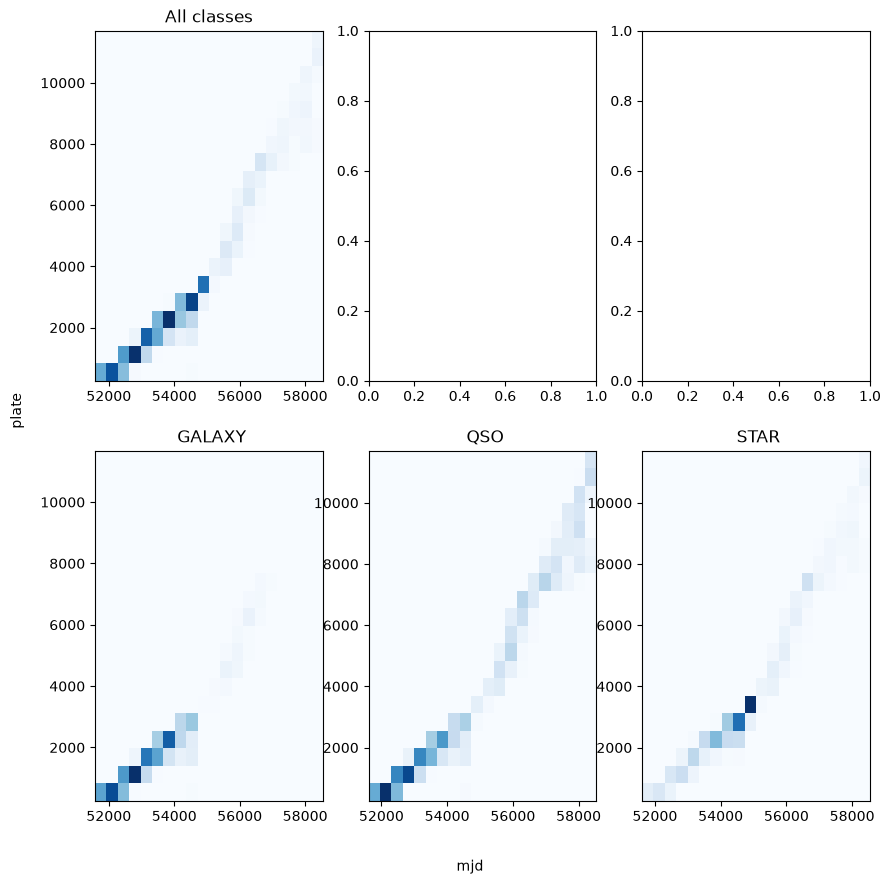

In [130]:
plot_2d_histogram(['mjd' , 'plate'])

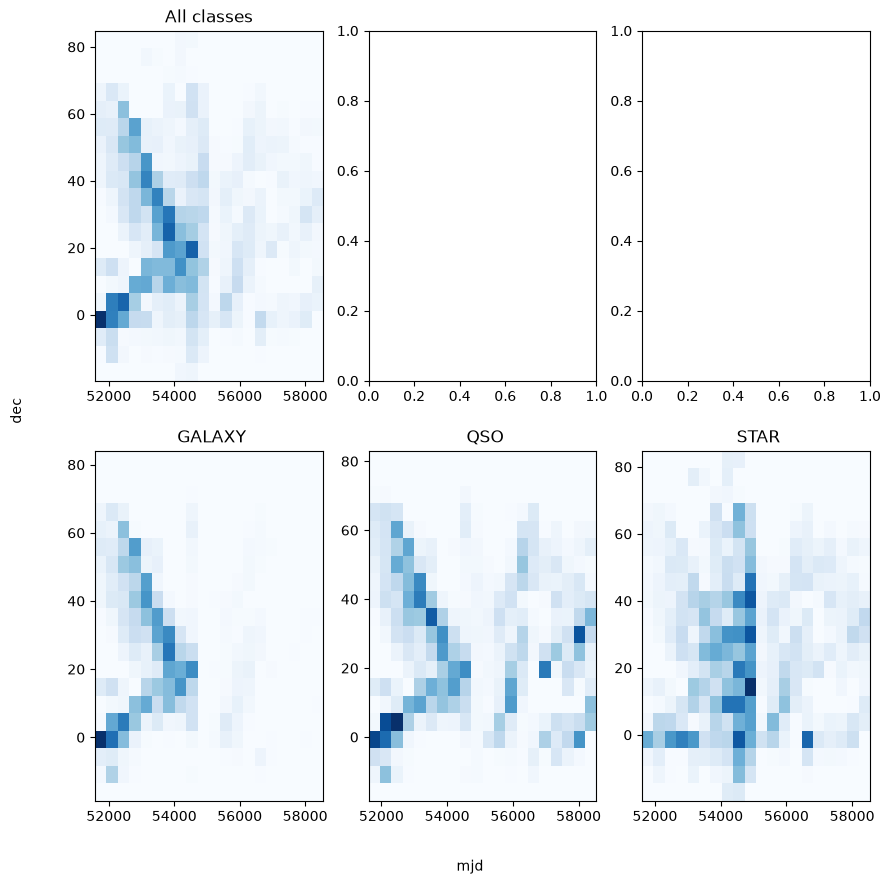

In [178]:
plot_2d_histogram(['mjd' , 'dec'])

In [196]:
df.groupby('class').size()

class
GALAXY    252216
QSO        54536
STAR      193241
dtype: int64

Trying a PCA decomposition

In [180]:
features.shape 

(499993, 10)

In [192]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_2d = pca.fit_transform(features)

print(len(pca_2d) , len(labels))

499993 499993


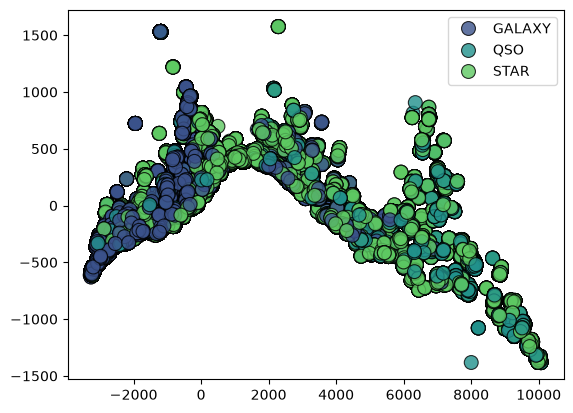

First most contributing component: 'plate' contributing at: , 98.24%
Second most contributing component: 'mjd' contributing at: 1.67%


In [ ]:
visualize_2d(x = pca_2d, labels = labels)

print(f"First most contributing component: '{feature_names[np.argmax(pca.components_[0])]}' contributing at: , {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Second most contributing component: '{feature_names[np.argmax(pca.components_[1])]}' contributing at: {pca.explained_variance_ratio_[1]*100:.2f}%")
#correlation of the highest pca

In [ ]:
import plotly.express as px

pca = PCA(n_components=3)
pca_3d = pca.fit_transform(features)

fig = px.scatter_3d(
    pca_3d, x=0, y=1, z=2,
    color=[f"Class {label}" for label in labels],
    labels={
        str(i): f"PC{i+1} ({ratio:.1%} variance)"
        for i, ratio in enumerate(pca.explained_variance_ratio_)
    },
    title="3D PCA — drag to rotate",
    opacity=0.8,
    height=650,
)
fig.update_traces(marker_size=5)
fig.show()

### ROC curves after PCA

PCA produces coordinates, so we add logistic regression to obtain a score for each class. We use the same features and three components as the latest PCA, adding standardization because the features have different units. This changes the PCA projection relative to the unscaled visualization.

We split the observations into 70% training and 30% test data, keeping class proportions. Scaling, PCA, and classification are fitted only on training data. Each ROC curve treats one class as positive and the other classes as negative, varying the probability threshold.

$$
\mathrm{TPR}=\frac{TP}{TP+FN},\qquad
\mathrm{FPR}=\frac{FP}{FP+TN}.
$$

Curves nearer the upper-left corner indicate better discrimination. AUC is 0.5 for random ranking and 1 for perfect ranking on this test set; it is not classification accuracy. These curves evaluate the classifier using PCA features, not PCA alone.

Reference: [scikit-learn multiclass ROC example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html).


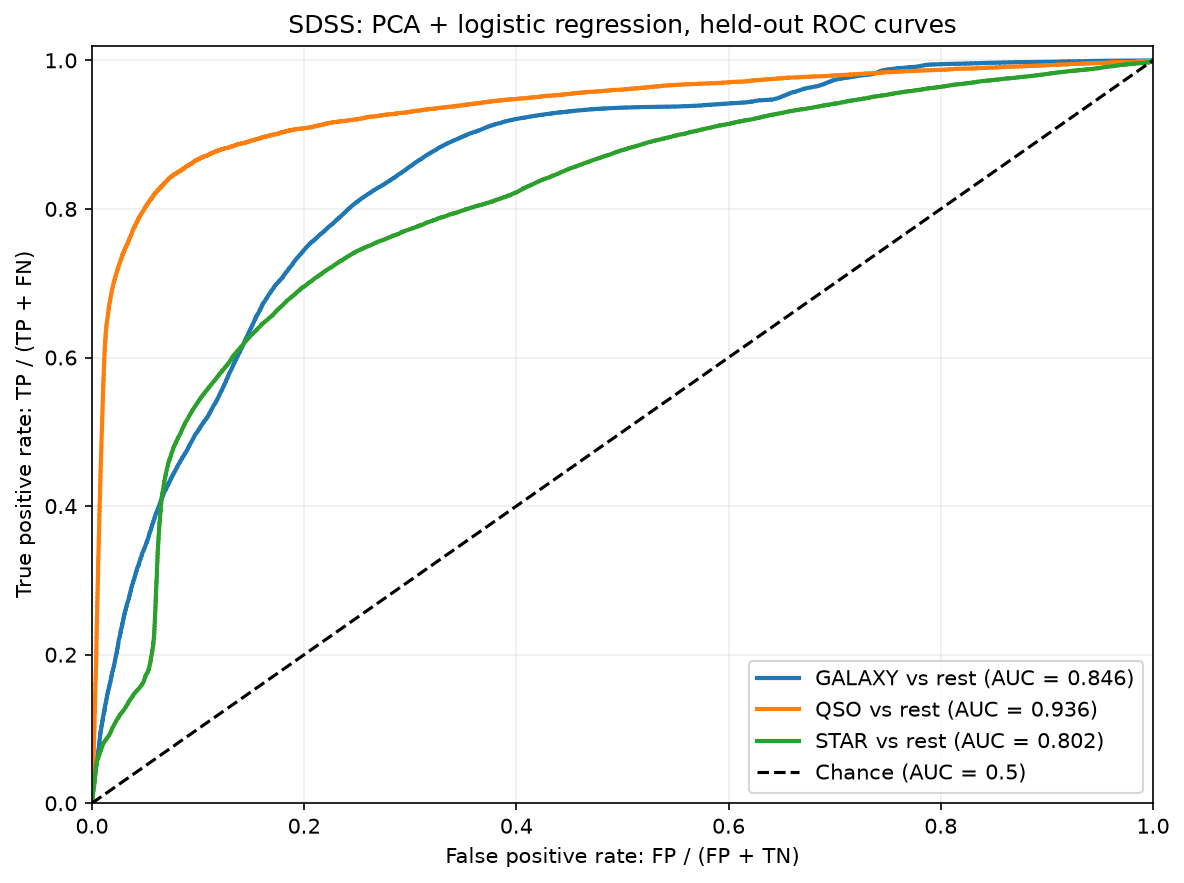

Executed using the data_analysis Python environment.
Training rows: 349,995; test rows: 149,998
Test ROC AUC: GALAXY = 0.845658; QSO = 0.935611; STAR = 0.802237
Variance retained by 3 PCs: 77.4%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc

# Keep the same features and three components as the latest PCA.
X_roc = features_df.copy()
y_roc = df.loc[X_roc.index, "class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_roc, y_roc, test_size=0.3, stratify=y_roc, random_state=2024
)

# Fit all preprocessing on training data only.
# Scaling prevents large numerical units (e.g. mjd) from dominating PCA.
roc_model = make_pipeline(
    StandardScaler(),
    PCA(n_components=3, svd_solver="full"),
    LogisticRegression(max_iter=2000),
)
roc_model.fit(X_train, y_train)
class_scores = roc_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
roc_auc_by_class = {}
for j, class_name in enumerate(roc_model.classes_):
    # This class is positive; all other classes are negative.
    fpr, tpr, thresholds = roc_curve(
        y_test == class_name, class_scores[:, j]
    )
    roc_auc_by_class[class_name] = auc(fpr, tpr)
    ax.plot(
        fpr, tpr, linewidth=2,
        label=f"{class_name} vs rest (AUC = {roc_auc_by_class[class_name]:.3f})",
    )
    distance_squared = fpr**2 + (1 - tpr)**2
    best_index = np.argmin(distance_squared)

    print("Best cut:", thresholds[best_index])
    print("TPR:", tpr[best_index])
    print("FPR:", fpr[best_index])

ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.5)")
ax.set(
    xlabel="False positive rate: FP / (FP + TN)",
    ylabel="True positive rate: TP / (TP + FN)",
    title="SDSS: PCA + logistic regression, held-out ROC curves",
    xlim=(0, 1), ylim=(0, 1.02),
)
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print("Test ROC AUC by class:", roc_auc_by_class)
print(
    "Variance retained by 3 PCs:",
    f"{roc_model.named_steps['pca'].explained_variance_ratio_.sum():.1%}",
)


### ROC curves from direct PCA cuts

For each class versus the rest, sweep a threshold on the existing first PCA coordinate. Compare both rules, PC1 >= cut and PC1 <= cut, and select the direction and finite threshold minimizing FPR squared + (1 - TPR) squared. Circles mark the selected operating points; the table reports cuts in the original PC1 units.

This is an exploratory evaluation on the whole dataset, with no additional classifier. The same labels select and evaluate the cuts, so the results describe this dataset rather than performance on unseen data. Separate one-versus-rest cuts may overlap or leave some observations unassigned.


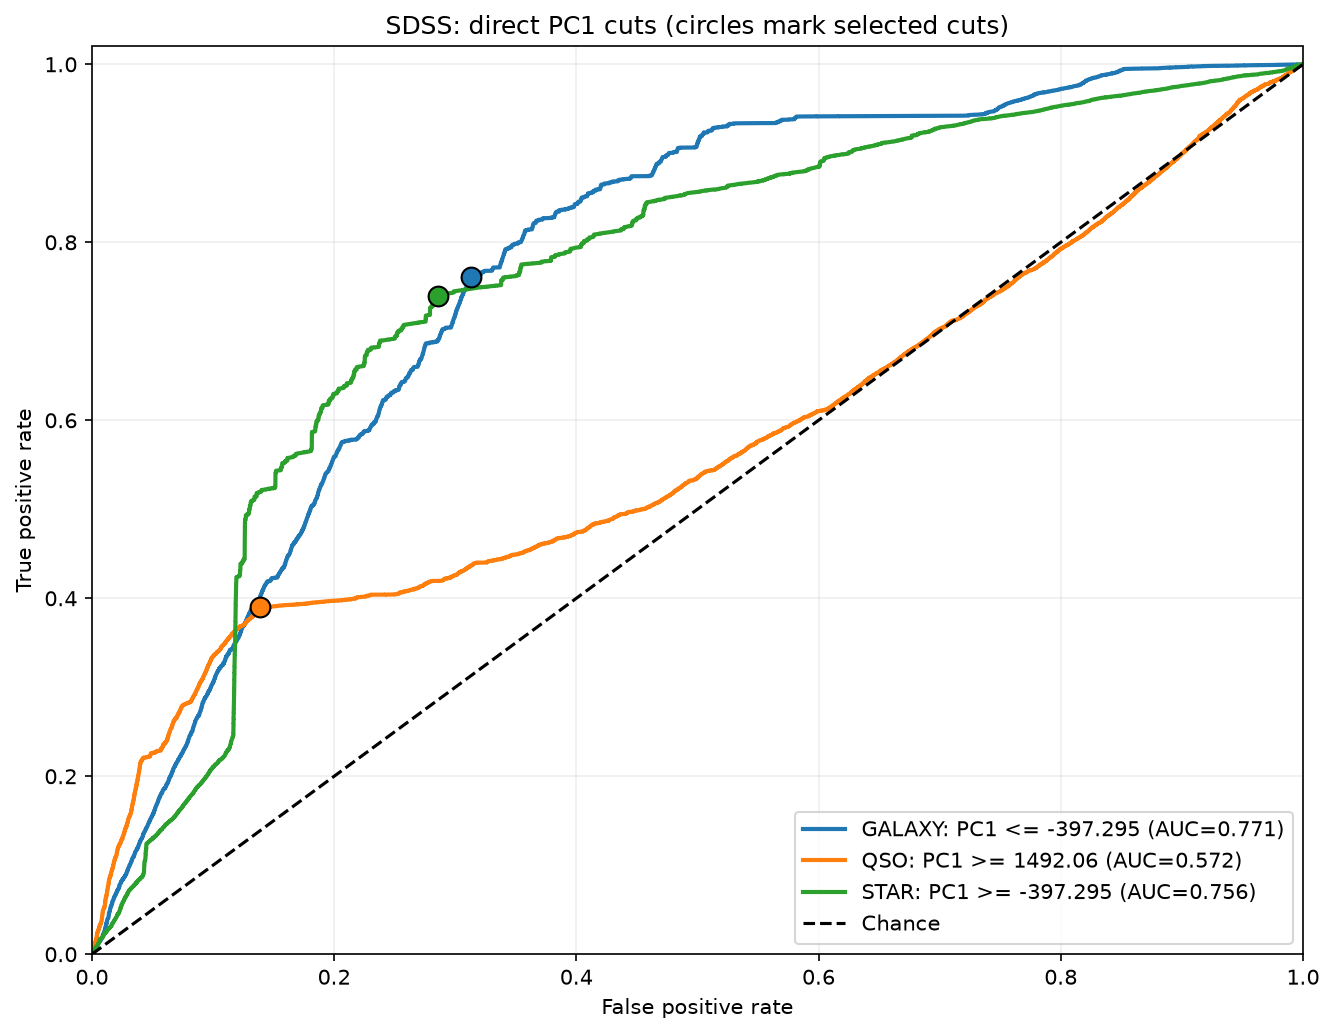

Class,Rule,PC1 cut,TPR,FPR,AUC,"Distance to (0, 1)"
GALAXY,PC1 <= -397.295,-397.295293,0.760543,0.313278,0.770582,0.394313
QSO,PC1 >= 1492.06,1492.058307,0.389871,0.139158,0.571602,0.625798
STAR,PC1 >= -397.295,-397.295249,0.739315,0.285843,0.755919,0.386863


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Reuse the existing, unscaled PCA coordinates for all observations.
pca_classes = df.loc[features_df.index, "class"].to_numpy()
pc1_scores = pca_2d[:, 0]
assert len(pca_classes) == len(pc1_scores), "Rerun PCA after filtering the data."

fig, ax = plt.subplots(figsize=(9, 7))
cut_rows = []

for class_name in np.unique(pca_classes):
    positive = pca_classes == class_name
    best = None

    # Test both tails of PC1 and minimize distance to (FPR=0, TPR=1).
    for direction in (1, -1):
        fpr, tpr, thresholds = roc_curve(
            positive, direction * pc1_scores, drop_intermediate=False
        )
        distance_squared = fpr**2 + (1 - tpr)**2
        distance_squared[~np.isfinite(thresholds)] = np.inf
        k = np.argmin(distance_squared)

        if best is None or distance_squared[k] < best["distance_squared"]:
            best = dict(
                direction=direction, fpr=fpr, tpr=tpr, index=k,
                cut=direction * thresholds[k],
                distance_squared=distance_squared[k],
            )

    fpr, tpr, k = best["fpr"], best["tpr"], best["index"]
    operator = ">=" if best["direction"] == 1 else "<="
    rule = f"PC1 {operator} {best['cut']:.6g}"
    curve_auc = auc(fpr, tpr)
    line, = ax.plot(
        fpr, tpr, linewidth=2,
        label=f"{class_name}: {rule} (AUC={curve_auc:.3f})",
    )
    ax.scatter(
        fpr[k], tpr[k], color=line.get_color(), marker="o",
        s=90, edgecolors="black", zorder=5,
    )
    cut_rows.append({
        "Class": class_name, "Rule": rule, "PC1 cut": best["cut"],
        "TPR": tpr[k], "FPR": fpr[k], "AUC": curve_auc,
        "Distance to (0, 1)": np.sqrt(best["distance_squared"]),
    })

ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set(
    xlabel="False positive rate", ylabel="True positive rate",
    title="SDSS: direct PC1 cuts (circles mark selected cuts)",
    xlim=(0, 1), ylim=(0, 1.02),
)
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

best_pca_cuts = pd.DataFrame(cut_rows)
display(best_pca_cuts)
